In [21]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import r3b
import ROOT
import seaborn as sns

%jsroot off

### Define parameter files with a unique label

Variables to setup:

- `root_path`: the root path used for the calibration of a certain experiment.
- `dir_path`: the subfolder name for a specific test
- `filenames_re`: a dictionary with the parameter label as its key and parameter file name as its value

In [49]:
root_path = "/lustre/r3b/ywang/test/s122"
dir_path = "test_aug18"
# dir_path = "test_Dec29"
filenames_re = {
    "recons": "recons.par.root",
    "millepede": r"millepede.test.0.\d.par.root",
}

In [50]:
def expand_filenames(dir_name, filenames):
    allfilenames = os.listdir(dir_name)
    new_filemap = {}

    for key, filename in filenames.items():
        pat = re.compile(filename)
        matched_filenames = [name for name in allfilenames if pat.match(name)]
        if len(matched_filenames) == 1:
            new_filemap[key] = matched_filenames[0]
        else:
            new_filemap.update(
                {
                    f"{key}_{idx}": matched_filename
                    for idx, matched_filename in enumerate(matched_filenames)
                }
            )
    return new_filemap

In [57]:
filenames = expand_filenames(f"{root_path}/{dir_path}", filenames_re)

Read the parameter values from files:

In [58]:
def read_hit_pars(root_dirs):
    all_dfs = []
    for key, filename in root_dirs.items():
        df = r3b.neuland.HitParReader(f"{root_path}/{dir_path}/{filename}").read(False)
        df["label"] = key
        all_dfs.append(df)
    return pd.concat(all_dfs, ignore_index=True)

In [245]:
all_pars = read_hit_pars(filenames)

In file recons.par.root 	> Cycle numbers read: [9999]
In file recons.par.root 	> Number of modules read: 1300. Cycle number: 9999
In file millepede.test.0.0.par.root 	> Cycle numbers read: [9999]
In file millepede.test.0.0.par.root 	> Number of modules read: 1300. Cycle number: 9999
In file millepede.test.0.1.par.root 	> Cycle numbers read: [9999]
In file millepede.test.0.1.par.root 	> Number of modules read: 1300. Cycle number: 9999


In [262]:
def reset_recon_to_ref_bar(pars, ref_bar_num):
    ref_t_sync = pars.loc[
        (pars["bar_id"] == (ref_bar_num - 1)) & (pars["label"] == "recons"),
        "t_sync.value",
    ].item()
    pars.loc[all_pars.label == "recons", "t_sync.value"] -= ref_t_sync
    # t_syncs = pars.loc[all_pars["label"] == "recons", "t_sync.value"]
    # t_syncs = t_syncs.sub(ref_t_sync)
    # pars.loc[all_pars["label"] == "recons", "t_sync.value"] = t_syncs

In [263]:
reference_module_num = 25
reset_recon_to_ref_bar(all_pars, reference_module_num)

## Parameter comparison:

In [234]:
def setup_axis(axis):
    axis.set_xticks(np.arange(0, 1301, step=100))
    axis.set_xticks(np.arange(0, 1301, step=50), minor=True)
    axis.set_xlim(0, 1300)
    axis.tick_params(axis="x", labelsize=13, labelrotation=-30)
    axis.tick_params(axis="y", labelsize=13)
    axis.grid(which="both", axis="x")
    axis.grid(which="minor", alpha=0.5)


def compare_par(par_name, pars, axis):
    # axes.set_xticks(np.arange(0, 1301, step=100))
    # axes.set_xticks(np.arange(0, 1301, step=50), minor=True)
    # axis.tick_params(axis="x", labelsize=13, labelrotation=-30)
    # axis.tick_params(axis="y", labelsize=13)
    data = pars
    sns.lineplot(data=pars, x="bar_id", y=par_name, ax=axis, hue="label")


def show_diff_pars(par_name, pars, base_label, other_label, axis):
    base_vals = pars[["bar_id", par_name, "label"]][pars["label"] == base_label]
    other_vals = pars[["bar_id", par_name, "label"]][pars["label"] == other_label]
    base_vals.sort_values(by=["bar_id"])
    other_vals.sort_values(by=["bar_id"])
    new_df = other_vals
    new_df["diff"] = other_vals[par_name].to_numpy() - base_vals[par_name].to_numpy()
    sns.lineplot(data=new_df, x="bar_id", y="diff", ax=axis)
    axis.set_title(f"difference between {base_label} and {other_label}")

In [266]:
labels = all_pars["label"].unique()
test_labels = [label for label in labels if label != "recons"]

### Check effective speed of light

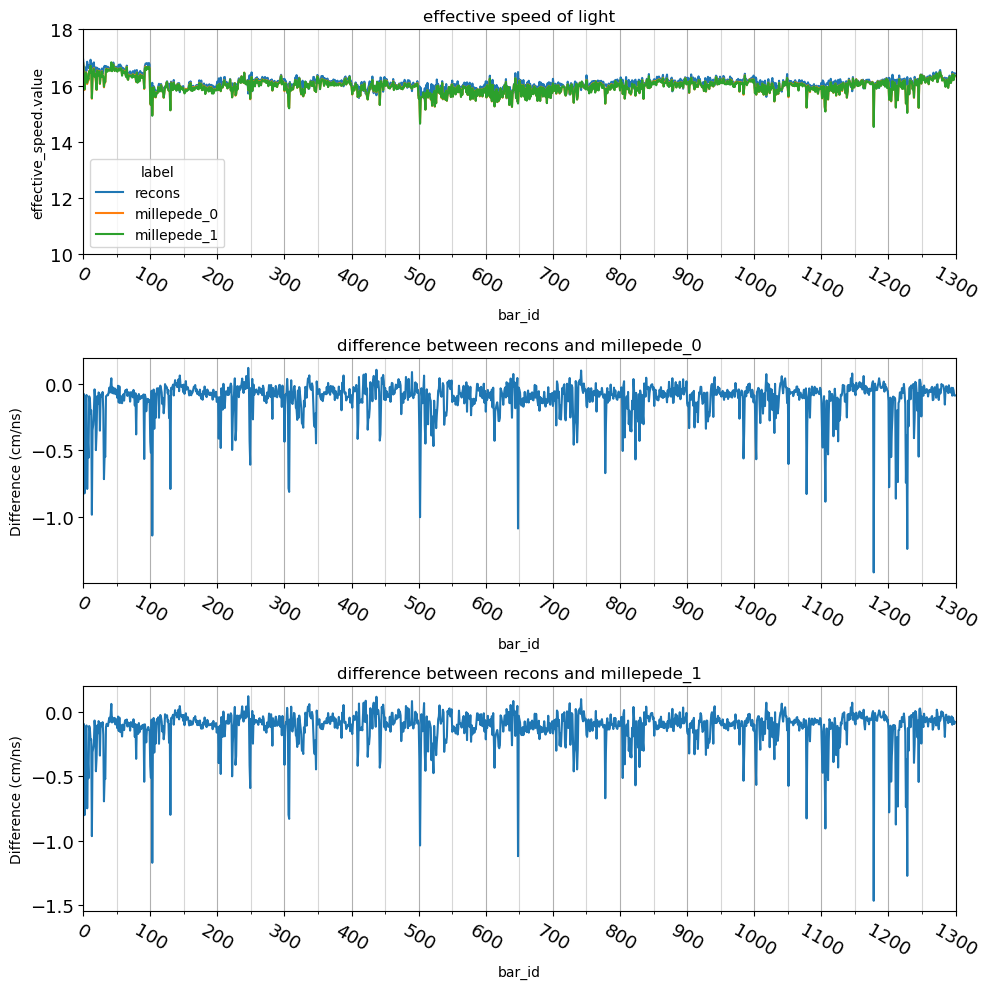

In [267]:
par_name = "effective_speed.value"
plot, axes = plt.subplots(nrows=len(labels), ncols=1, figsize=[10, 10])
for axis in axes:
    setup_axis(axis)
compare_par(par_name, all_pars, axes[0])
for idx, label in enumerate(test_labels):
    show_diff_pars(par_name, all_pars, "recons", label, axes[idx + 1])
    axes[idx + 1].set_ylabel("Difference (cm/ns)")
axes[0].set_ylim(10, 18)
axes[0].set_title("effective speed of light")
plot.tight_layout()
# axes.set(ylim=(-10, 20));
# axes.set(xlim=(1200, 1300))

### Check time synchronization

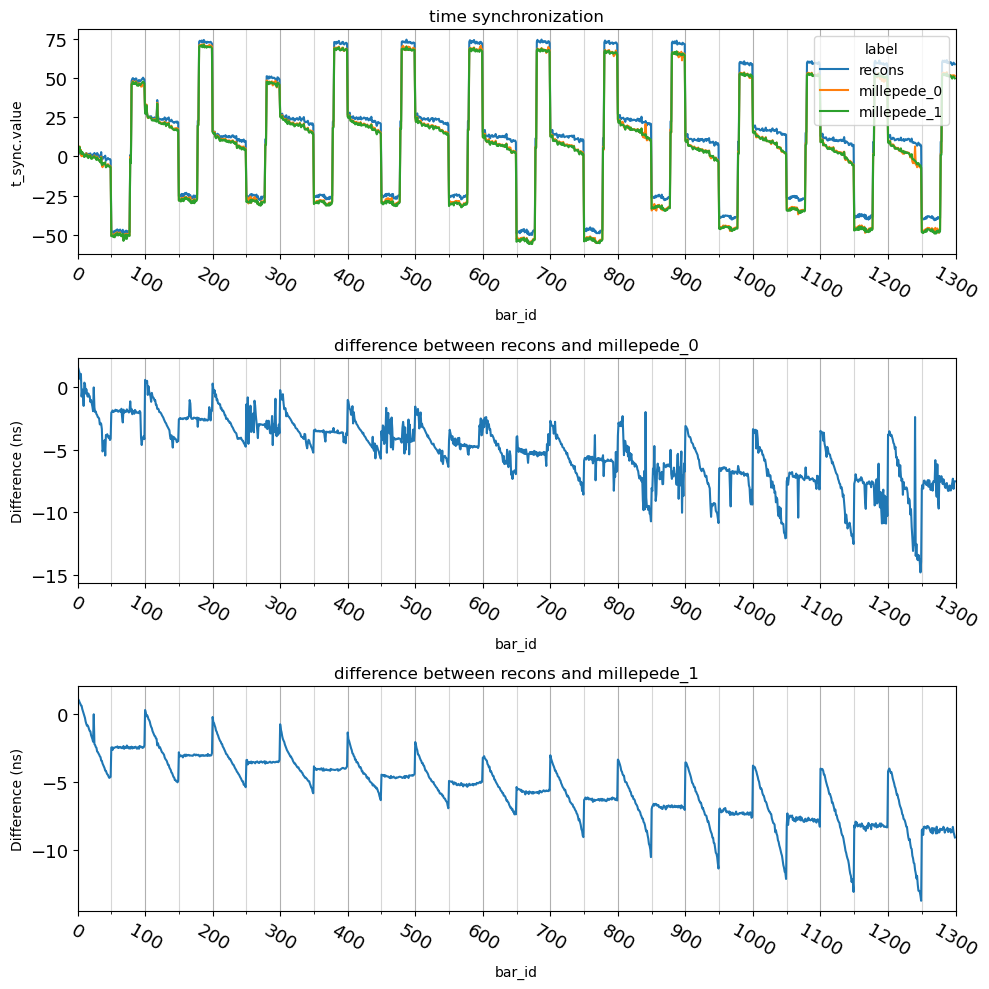

In [268]:
labels = all_pars["label"].unique()
plot, axes = plt.subplots(nrows=len(labels), ncols=1, figsize=[10, 10])
for axis in axes:
    setup_axis(axis)
compare_par("t_sync.value", all_pars, axes[0])
for idx, label in enumerate(test_labels):
    show_diff_pars("t_sync.value", all_pars, "recons", label, axes[idx + 1])
    axes[idx + 1].set_ylabel("Difference (ns)")
# axes[0].set_ylim(10, 18)
axes[0].set_title("time synchronization")
plot.tight_layout()

### Check time difference between two adjacent PMTs

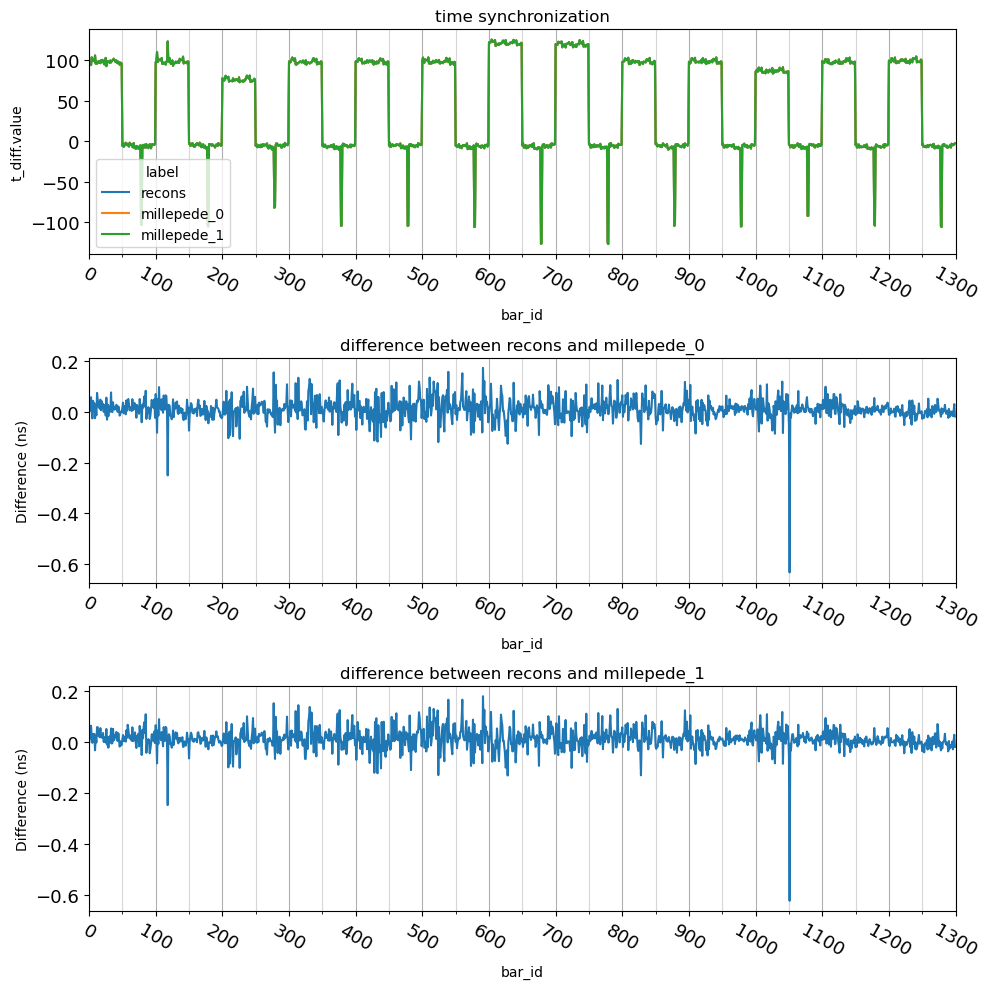

In [269]:
labels = all_pars["label"].unique()
par_name = "t_diff.value"
plot, axes = plt.subplots(nrows=len(labels), ncols=1, figsize=[10, 10])
for axis in axes:
    setup_axis(axis)
compare_par(par_name, all_pars, axes[0])
for idx, label in enumerate(test_labels):
    show_diff_pars(par_name, all_pars, "recons", label, axes[idx + 1])
    axes[idx + 1].set_ylabel("Difference (ns)")
# axes[0].set_ylim(10, 18)
axes[0].set_title("time synchronization")
plot.tight_layout()